# MOCSII Chronicity Simulation — v4 (optimized)

**Goal of this rewrite:** run more agents, over a wider parameter sweep, without
the multi-hour/multi-day runtimes of the original — plus cleaner static and
interactive visualizations.



## 1. Setup

In [2]:
# Imports
import heapq
import math
import pickle     # Used to save and load parameter sweep data
import time
from dataclasses import dataclass, field    # What is this used for?
from pathlib import Path
from typing import Optional, Sequence     # What is this used for?
from concurrent.futures import ProcessPoolExecutor, as_completed    # This executes parallel processes asynchronously
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

try:
    import plotly.express as px
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("plotly not found - interactive visualization cells will raise a clear error until you "
          "`pip install plotly` (Colab has it pre-installed).")

MONTH_LEN = 30.44      # days/month (~365/12)
N_MONTHS = 36           # 36-month observation window
DEFAULT_T = 365 * 3     # 1,095 days = 3 years

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Known issues found in the original notebook

While reading the original code closely enough to optimize it, three
implementation-level issues turned up. None of these are about the *modeling
approach* (ph / pe / pu / exit decay / chronicity definitions are all
unchanged) — they're bugs in how the original code was written. All three are
**off by default** below (`fix_known_bugs=False`), so v2's numbers stay
backward-comparable with what's already in your paper. Pass
`fix_known_bugs=True` to any of the run functions to use the corrected
versions instead.

1. **`exit_homelessness()` referenced undefined names.** It called
   `self.amIchronic(time, consecutive_pop, episodic_pop)` — but `time`,
   `consecutive_pop`, and `episodic_pop` are not parameters of that method.
   This only ran without crashing because the notebook's *global* namespace
   happened to contain variables with those exact names at the time it was
   called. This one is just fixed (not toggleable) since it can't be faithfully
   reproduced outside a notebook's global scope.

2. **`consecutive_test()` has a negative-index bug.** It loops
   `range(this_month, this_month - 14, -1)`, which produces negative indices
   whenever `this_month < 13` — i.e., for anyone within their first ~13
   simulated months. Python silently wraps negative list indices to the *end*
   of the list, so this was accidentally reading months 22-35 instead of
   stopping at month 0. This can affect consecutive-chronicity classification
   early in a person's homelessness history.

3. **A stale-event-type bug in the main loop.** The original reuses a single
   `homeless_event` variable across the *entire* while loop rather than
   scoping it per-person. In the specific branch where a `'homeless'` event
   fires for someone who is *already* homeless, the code never reassigns
   `homeless_event` — so it silently keeps whatever value was left over from
   the *previous* iteration, which may belong to a different person's event
   entirely. This determines what kind of event gets scheduled next for that
   person, so it's a genuine (if subtle and probably rare) correctness issue.

We'd recommend running the sweep once with `fix_known_bugs=False` (matches
your paper) and once with `True`, and eyeballing whether the headline
findings (e.g., the p_u sensitivity results) hold up — that tells you whether
these were cosmetic or load-bearing.

## 3. Core simulation (optimized)

Same `Person` semantics, same three event types, same exponential draws,
same chronicity rules as the original. Comments marked `V2:` explain each
change.

The cell below writes `sim_core_v2.py` to disk (into the same folder as this
notebook) and imports it, rather than just defining these functions directly
in a cell. This matters for Section 6: `ProcessPoolExecutor` has to ship
these functions to worker processes, which means pickling them. Functions
defined directly in a notebook cell only survive that trip on Linux (which
uses the `fork` start method, e.g. Colab); on macOS and Windows (`spawn`),
the exact same code would fail with
`PicklingError: Can't pickle <function ...>: attribute lookup ... on __main__ failed`.
Writing to a real, importable `.py` file sidesteps that on every platform —
and because the notebook writes the file itself, you don't need to remember
to upload a companion file alongside it.

In [2]:
%%writefile /content/drive/MyDrive/sim_core_v2.py

import heapq
import time
from dataclasses import dataclass, field
import numpy as np

MONTH_LEN = 30.44      # days/month (~365/12)
N_MONTHS = 36           # 36-month observation window
DEFAULT_T = 365 * 3     # 1,095 days = 3 years

sys.path.append('/content/drive/MyDrive/')

class Person:
    __slots__ = (
        "amIhomeless", "num_eps", "num_months", "num_undetected_months",
        "consecutive", "episodic", "months_homeless", "months_detected",
        "this_episode_months", "ep_and_cons", "p_exit", "ever_episodic",
        "ever_consecutive", "ever_homeless", "index",
    )
    # __slots__ is a small memory/speed optimization for large populations

    def __init__(self):
        self.amIhomeless = False
        self.num_eps = 0
        self.num_months = 0
        self.num_undetected_months = 0
        self.consecutive = False
        self.episodic = False
        self.months_homeless = [False] * N_MONTHS
        self.months_detected = [True] * N_MONTHS
        self.this_episode_months = 0
        self.ep_and_cons = False
        self.p_exit = 0.0
        self.ever_episodic = False
        self.ever_consecutive = False
        self.ever_homeless = False
        self.index = 0

    def _month_index(self, t):
        return min(int(t // MONTH_LEN), N_MONTHS - 1)    # // is a floor division
                                                    # operator - returns the
                                                    # rounded-down integer from
                                                    # division

    def shouldIaddmonth(self, t, p_e_base):
        this_month = self._month_index(t)
        if not self.months_homeless[this_month]:
            for month in range(this_month, N_MONTHS):
                self.months_homeless[month] = True
            self.num_months = sum(self.months_homeless[: this_month + 1])
            # Counts total # of months homeless to determine whether > 12 in 36
            # months
            self.num_eps += 1
            self.amIhomeless = True
            self.this_episode_months += 1
            self.p_exit = p_e_base ** self.this_episode_months
            # Fixed this from original b/c v1 used number of lifetime homeless
            # months as exponent, rather than current episode only

    def amIchronic(self, t, fix_known_bugs=True):
        if self.num_months > 12 and self.num_eps >= 4:
            self.episodic = True
            self.ever_episodic = True
        if self.num_months > 12 and self.num_eps < 4:
            self.episodic = False
            this_month = self._month_index(t)
            if consecutive_test(self.months_homeless, this_month, fix_known_bugs=fix_known_bugs):
                self.consecutive = True
                self.ever_consecutive = True
            else:
                self.consecutive = False
        if self.consecutive and self.episodic:
            self.ep_and_cons = True

    def addundetectedmonth(self, t):
        this_month = self._month_index(t)
        if self.months_detected[this_month]:
            self.months_detected[this_month] = False
            self.num_undetected_months += 1

    def makemehomeless(self, t, p_undetected, p_e_base, rng, fix_known_bugs=True):    # I can include rng as an argument?!
        self.shouldIaddmonth(t, p_e_base)
        self.amIhomeless = True
        self.ever_homeless = True
        self.amIchronic(t, fix_known_bugs=fix_known_bugs)
        if rng.random() < (self.p_exit / (p_undetected + self.p_exit)):
            return "exit"
        return "undetected"

    def exit_homelessness(self, t, p_e_base, fix_known_bugs=True):
        self.amIhomeless = False
        this_month = self._month_index(t)
        for month in range(this_month + 1, N_MONTHS):
            self.months_homeless[month] = False
        self.amIchronic(t, fix_known_bugs=fix_known_bugs)
        self.p_exit = p_e_base
        self.this_episode_months = 0


def consecutive_test(months_homeless, this_month, fix_known_bugs=False):
    """Checks the trailing 13 months (inclusive) for >12 True values."""
    counter = 0
    if fix_known_bugs:
        lo = max(this_month - 13, -1)  # Yoshi: Check this
    else:
        lo = this_month - 14  # Yoshi: Check this
    for x in range(this_month, lo, -1):
        if months_homeless[x]:
            counter += 1
        if counter > 12:
            return True
    return False


def _draw_tau(rng, p_h, p_u, p_e, event_type):    # DEFINITELY CHECK THIS!!!
    if event_type == "exit":
        return rng.exponential(1.0 / p_e)
    elif event_type == "undetected":
        return rng.exponential(1.0 / p_u)
    else:
        return rng.exponential(1.0 / p_h)


@dataclass                # Creates a class primarily used to "hold state"
class RunResult:
    p_h: float
    p_e: float
    p_u: float
    sim: int
    n_consecutive: int
    n_episodic: int
    n_chronic: int
    n_ever_homeless: int
    n_undetected_chronic: int
    frac_undetected_chronic: float
    wall_time_sec: float
    times: list = field(default_factory=list)
    now_homeless_ts: list = field(default_factory=list)
    ever_homeless_ts: list = field(default_factory=list)
    consecutive_ts: list = field(default_factory=list)
    episodic_ts: list = field(default_factory=list)


def _find_undetected_chronic_vectorized(population):
    episodic_people = [p for p in population if p.ever_episodic]
    if not episodic_people:
        return 0, float("nan")

    H = np.array([p.months_homeless for p in episodic_people], dtype=bool)
    D = np.array([p.months_detected for p in episodic_people], dtype=bool)
    detected_homeless = H & D            # detected_homeless is an array where each entry is True iff H and D are both True

    detected_num_months = detected_homeless.sum(axis=1)          # Counts the number of detected homeless months (Trues) in detected_homeless
    prev = np.zeros((detected_homeless.shape[0], 1), dtype=bool)   # Creates an array of zeroes but why is dtype bool?
    shifted = np.concatenate([prev, detected_homeless[:, :-1]], axis=1)     # What is going on here?
    new_episode_starts = detected_homeless & ~shifted
    detected_num_eps = new_episode_starts.sum(axis=1)

    would_be_missed = (detected_num_eps < 4) | (detected_num_months < 12)     # What is this syntax? What is happening here?
    n_undetected = int(would_be_missed.sum())
    frac_undetected = n_undetected / len(episodic_people)
    return n_undetected, frac_undetected


def simulate_single_run(p_h, p_e_base, p_u, size_pop=200_000, T=DEFAULT_T, sim_id=0,
                          seed=None, record_timeseries=True, fix_known_bugs=False):
    """
    V2 optimized single-simulation runner. Same event-driven algorithm, RNG draw
    order, and per-agent stochastic rules as the original; changes are (a) O(1)
    running counters instead of O(N) rescans every event, and (b) the opt-in
    bug fixes described in Section 2.
    """
    _start = time.perf_counter()
    rng = np.random.default_rng(seed)

    population = [Person() for _ in range(size_pop)]
    for i, person in enumerate(population):
        person.p_exit = p_e_base
        person.index = i
        if rng.random() < p_h:
            person.amIhomeless = True
            person.ever_homeless = True
            person.shouldIaddmonth(0, p_e_base)

    now_homeless_count = sum(1 for p in population if p.amIhomeless)
    ever_homeless_count = sum(1 for p in population if p.ever_homeless)
    ever_consecutive_count = 0
    ever_episodic_count = 0

    event_queue = []
    for i, person in enumerate(population):
        if person.amIhomeless and rng.random() < p_e_base / (p_u + p_e_base):
            event_type = "exit"
        elif person.amIhomeless:
            event_type = "undetected"
        else:
            event_type = "homeless"
        tau = _draw_tau(rng, p_h, p_u, p_e_base, event_type)
        heapq.heappush(event_queue, (tau, i, event_type))

    times, now_ts, ever_ts, cons_ts, epis_ts = [], [], [], [], []
    homeless_event = "homeless"  # mirrors the ORIGINAL's single reused scalar (issue #3)

    while event_queue:
        t, idx, event = heapq.heappop(event_queue)
        if t >= T:
            break
        person = population[idx]

        if event == "homeless":
            if not person.amIhomeless:
                was_ever_h = person.ever_homeless
                was_cons, was_epis = person.ever_consecutive, person.ever_episodic
                homeless_event = person.makemehomeless(t, p_u, p_e_base, rng, fix_known_bugs=fix_known_bugs)
                now_homeless_count += 1
                if person.ever_homeless and not was_ever_h:
                    ever_homeless_count += 1
                if person.ever_consecutive and not was_cons:
                    ever_consecutive_count += 1
                if person.ever_episodic and not was_epis:
                    ever_episodic_count += 1
            else:
                person.shouldIaddmonth(t, p_e_base)
                if fix_known_bugs:
                    homeless_event = "exit" if rng.random() < (person.p_exit / (p_u + person.p_exit)) else "undetected"
                # else: intentionally NOT reassigned - reproduces issue #3.
        elif event == "undetected" and person.amIhomeless:
            person.addundetectedmonth(t)
            homeless_event = "exit" if rng.random() < (person.p_exit / (p_u + person.p_exit)) else "undetected"
        elif event == "exit" and person.amIhomeless:
            was_cons, was_epis = person.ever_consecutive, person.ever_episodic
            person.exit_homelessness(t, p_e_base, fix_known_bugs=fix_known_bugs)
            now_homeless_count -= 1
            if person.ever_consecutive and not was_cons:
                ever_consecutive_count += 1
            if person.ever_episodic and not was_epis:
                ever_episodic_count += 1
            homeless_event = "homeless"

        person.num_months = sum(person.months_homeless[: person._month_index(t) + 1])

        tau = _draw_tau(rng, p_h, p_u, person.p_exit, homeless_event)
        heapq.heappush(event_queue, (t + tau, idx, homeless_event))

        if record_timeseries:
            times.append(t)
            now_ts.append(now_homeless_count)
            ever_ts.append(ever_homeless_count)
            cons_ts.append(ever_consecutive_count)
            epis_ts.append(ever_episodic_count)

    last_month = min(int((T - 1) // MONTH_LEN), N_MONTHS - 1)
    for person in population:
        person.num_months = sum(person.months_homeless[: last_month + 1])
        person.amIchronic(T, fix_known_bugs=fix_known_bugs)

    n_consecutive = sum(1 for p in population if p.ever_consecutive)
    n_episodic = sum(1 for p in population if p.ever_episodic)
    n_ever_homeless = sum(1 for p in population if p.ever_homeless)
    n_chronic = n_consecutive + n_episodic
    n_undetected, frac_undetected = _find_undetected_chronic_vectorized(population)

    wall = time.perf_counter() - _start
    return RunResult(
        p_h=p_h, p_e=p_e_base, p_u=p_u, sim=sim_id,
        n_consecutive=n_consecutive, n_episodic=n_episodic, n_chronic=n_chronic,
        n_ever_homeless=n_ever_homeless,
        n_undetected_chronic=n_undetected, frac_undetected_chronic=frac_undetected,
        wall_time_sec=wall,
        times=times, now_homeless_ts=now_ts, ever_homeless_ts=ever_ts,
        consecutive_ts=cons_ts, episodic_ts=epis_ts,
    )

Overwriting /content/drive/MyDrive/sim_core_v2.py


## 4. Parallel parameter sweep

What I previously tested:
P_h = # [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.025]
P_e = [0.01, 0.125, 0.15, 0.175, 0.05, 0.1, 0.2, 0.5]
P_u = [0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.25]

In [5]:
%%writefile /content/drive/MyDrive/sim_sweep_v2.py

import pickle
import time
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

import pandas as pd

from sim_core_v2 import DEFAULT_T, simulate_single_run

sys.path.append('/content/drive/MyDrive/')

def _sweep_worker(args):
    p_h, p_e, p_u, sim_id, size_pop, T, seed, record_timeseries, fix_known_bugs = args
    return simulate_single_run(p_h, p_e, p_u, size_pop=size_pop, T=T, sim_id=sim_id, seed=seed,
                                 record_timeseries=record_timeseries, fix_known_bugs=fix_known_bugs)


def run_sweep(P_h, P_e, P_u, numsims=5, size_pop=10_000, T=DEFAULT_T,
              record_timeseries=True, fix_known_bugs=False, n_workers=None,
              base_seed=None, progress=True):
    """base_seed=None (default) reproduces the original's fully-random behavior.
    Pass an int for reproducible sweeps (useful while debugging/validating)."""
    jobs = []
    for sim in range(numsims):
        for p_h in P_h:
            for p_e in P_e:
                for p_u in P_u:
                    seed = None if base_seed is None else hash((base_seed, sim, p_h, p_e, p_u)) & 0xFFFFFFFF     #WTAF
                    jobs.append((p_h, p_e, p_u, sim, size_pop, T, seed, record_timeseries, fix_known_bugs))

    results = []
    t_start = time.perf_counter()
    report_every = max(1, len(jobs) // 20)
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futures = [ex.submit(_sweep_worker, job) for job in jobs]
        completed = 0
        for fut in as_completed(futures):
            results.append(fut.result())
            completed += 1
            if progress and (completed % report_every == 0 or completed == len(jobs)):
                print(f"{completed}/{len(jobs)} runs complete ({time.perf_counter()-t_start:.1f}s elapsed)")

    summary_df = pd.DataFrame([{
        "P homeless": r.p_h, "P exit": r.p_e, "P undetected": r.p_u, "Simulation": r.sim,
        "# Consecutive": r.n_consecutive, "# Episodic": r.n_episodic, "# Chronic": r.n_chronic,
        "# Ever Homeless": r.n_ever_homeless, "# Undetected Chronic": r.n_undetected_chronic,
        "Frac Undetected Chronic": r.frac_undetected_chronic, "Wall Time (s)": r.wall_time_sec,
    } for r in results])
    summary_df["Episodic as % Chronic"] = summary_df["# Episodic"] / summary_df["# Chronic"]

    timeseries = {
        (r.sim, r.p_h, r.p_e, r.p_u): {
            "Times": r.times, "Now_homeless": r.now_homeless_ts, "Ever_homeless": r.ever_homeless_ts,
            "Consecutive_counts": r.consecutive_ts, "Episodic_counts": r.episodic_ts,
        } for r in results
    }
    print(f"Sweep complete: {len(jobs)} runs in {time.perf_counter()-t_start:.1f}s wall-clock "
          f"(sum of individual run times: {summary_df['Wall Time (s)'].sum():.1f}s)")
    return summary_df, timeseries


def save_sweep(summary_df, timeseries, out_dir="sweep_results", tag="sweep"):
    out_dir = Path(out_dir); out_dir.mkdir(exist_ok=True, parents=True)
    summary_path, ts_path = out_dir / f"{tag}_summary.csv", out_dir / f"{tag}_timeseries.pkl"
    summary_df.to_csv(summary_path, index=False)
    with open(ts_path, "wb") as f:
        pickle.dump(timeseries, f)
    print(f"Saved {summary_path} and {ts_path}")
    return summary_path, ts_path


def load_sweep(out_dir="sweep_results", tag="sweep"):
    out_dir = Path(out_dir)
    summary_df = pd.read_csv(out_dir / f"{tag}_summary.csv")
    with open(out_dir / f"{tag}_timeseries.pkl", "rb") as f:
        timeseries = pickle.load(f)
    return summary_df, timeseries

Overwriting /content/drive/MyDrive/sim_sweep_v2.py


## Run simulation after crashing

In [3]:
sys.path.append('/content/drive/MyDrive/')

from sim_core_v2 import (
    Person, consecutive_test, _draw_tau, RunResult,
    _find_undetected_chronic_vectorized, simulate_single_run,
    MONTH_LEN, N_MONTHS, DEFAULT_T,
)

In [4]:
from sim_sweep_v2 import run_sweep, save_sweep, load_sweep

In [7]:
# Identify values for the parameter sweeps and run the code here

P_h_example = [0.0025, 0.005, 0.0075, 0.01, 0.0125]
P_e_example = [0.0025, 0.005, 0.0075, 0.01, 0.0125]
P_u_example = [0.05]

summary_df, timeseries = run_sweep(
    P_h_example, P_e_example, P_u_example,
    numsims=5, size_pop=20000, T=DEFAULT_T,
    record_timeseries=True, fix_known_bugs=True,
    n_workers=None, base_seed=None,
)
save_sweep(summary_df, timeseries, out_dir="sweep_results", tag="example")
summary_df.head()

6/125 runs complete (18.5s elapsed)
12/125 runs complete (38.8s elapsed)
18/125 runs complete (65.8s elapsed)
24/125 runs complete (98.1s elapsed)
30/125 runs complete (113.4s elapsed)
36/125 runs complete (135.0s elapsed)
42/125 runs complete (159.7s elapsed)
48/125 runs complete (186.0s elapsed)
54/125 runs complete (204.5s elapsed)
60/125 runs complete (226.8s elapsed)
66/125 runs complete (250.6s elapsed)
72/125 runs complete (278.0s elapsed)
78/125 runs complete (297.1s elapsed)
84/125 runs complete (314.3s elapsed)
90/125 runs complete (340.2s elapsed)
96/125 runs complete (366.1s elapsed)
102/125 runs complete (391.7s elapsed)
108/125 runs complete (410.5s elapsed)
114/125 runs complete (432.5s elapsed)
120/125 runs complete (459.2s elapsed)
125/125 runs complete (480.0s elapsed)
Sweep complete: 125 runs in 480.0s wall-clock (sum of individual run times: 921.8s)
Saved sweep_results/example_summary.csv and sweep_results/example_timeseries.pkl


,P homeless,P exit,P undetected,Simulation,# Consecutive,# Episodic,# Chronic,# Ever Homeless,# Undetected Chronic,Frac Undetected Chronic,Wall Time (s),Episodic as % Chronic
0,0.0025,0.0050,0.05,0,6463,159,6622,18668,65,0.408805,4.189865,0.024011
1,0.0025,0.0025,0.05,0,11099,8,11107,18738,0,0.000000,5.191769,0.000720
2,0.0025,0.0075,0.05,0,3971,464,4435,18703,191,0.411638,3.669897,0.104622
3,0.0025,0.0100,0.05,0,2421,857,3278,18687,426,0.497083,3.453828,0.261440
4,0.0025,0.0125,0.05,0,1523,1340,2863,18659,729,0.544030,4.757910,0.468041


## 7. Load previously saved results

Skip re-running simulations entirely once you have a saved sweep — useful
when you just want to iterate on visualizations.

In [5]:
summary_df, timeseries = load_sweep(out_dir="sweep_results", tag="example")
summary_df.head()

,P homeless,P exit,P undetected,Simulation,# Consecutive,# Episodic,# Chronic,# Ever Homeless,# Undetected Chronic,Frac Undetected Chronic,Wall Time (s),Episodic as % Chronic
0,0.0025,0.0050,0.05,0,6463,159,6622,18668,65,0.408805,4.189865,0.024011
1,0.0025,0.0025,0.05,0,11099,8,11107,18738,0,0.000000,5.191769,0.000720
2,0.0025,0.0075,0.05,0,3971,464,4435,18703,191,0.411638,3.669897,0.104622
3,0.0025,0.0100,0.05,0,2421,857,3278,18687,426,0.497083,3.453828,0.261440
4,0.0025,0.0125,0.05,0,1523,1340,2863,18659,729,0.544030,4.757910,0.468041


## 8. Static visualizations

In [6]:
def set_style():
    sns.set_theme(style="whitegrid", font_scale=1.3)
    plt.rcParams["figure.dpi"] = 150
    plt.rcParams["savefig.dpi"] = 300
    plt.rcParams["axes.titleweight"] = "bold"

METRIC_LABELS = {
    "# Ever Homeless": "Ever homeless (count)",
    "# Consecutive": "Ever consecutively chronic (count)",
    "# Episodic": "Ever episodically chronic (count)",
    "Episodic as % Chronic": "Episodic (% of all chronic)",
}

def plot_heatmap_grid(summary_df, x_param, y_param, metrics=None, agg="mean",
                       fixed_params_note=None, save_path=None, cmap="plasma"):
    set_style()
    if metrics is None:
        metrics = list(METRIC_LABELS.keys())
    ncols = 2
    nrows = int(np.ceil(len(metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 8 * nrows))
    axes = np.atleast_1d(axes).flatten()
    x_vals = sorted(summary_df[x_param].unique())
    y_vals = sorted(summary_df[y_param].unique(), reverse = True)
    for i, metric in enumerate(metrics):
        pivot = summary_df.pivot_table(index=y_param, columns=x_param, values=metric, aggfunc=agg)
        pivot = pivot.reindex(index=y_vals, columns=x_vals)
        sns.heatmap(pivot, ax=axes[i], annot=True, fmt='.2f', cmap=cmap,
                    annot_kws={"size": 11}, cbar_kws={"label": metric})
        axes[i].set_title(METRIC_LABELS.get(metric, metric))
        axes[i].set_xlabel(x_param); axes[i].set_ylabel(y_param)
    for j in range(len(metrics), len(axes)):
        axes[j].axis("off")
    title = f"Chronicity outcomes averaged across simulations ({agg})\nP undetected = 0.05"
    if fixed_params_note:
        title += f"\n{fixed_params_note}"
    fig.suptitle(title, y=1.02, fontsize=16)
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
    return fig


def plot_timeseries(timeseries, keys, title=None, save_path=None, logy=False):
    set_style()
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = {"Ever_homeless": "#1f77b4", "Consecutive_counts": "#2ca02c", "Episodic_counts": "#7f7f7f"}
    labels_used = set()
    for key in keys:
        if key not in timeseries:
            continue
        series = timeseries[key]
        for col, label in [("Ever_homeless", "Ever homeless"), ("Consecutive_counts", "Ever consecutive"),
                            ("Episodic_counts", "Ever episodic")]:
            lbl = label if label not in labels_used else None
            ax.plot(series["Times"], series[col], color=colors[col], alpha=0.5, label=lbl)
            labels_used.add(label)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("Timestep (days)"); ax.set_ylabel("Count")
    ax.set_title(title or "System-wide chronicity counts over time")
    ax.legend()
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
    return fig


def plot_undetected_stripplot(summary_df, x_param, hue_param, save_path=None):
    set_style()
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.stripplot(data=summary_df, x=x_param, y="Frac Undetected Chronic", hue=hue_param,
                  dodge=True, jitter=True, alpha=0.75, palette="Set1", ax=ax)
    ax.set_title(f"Undetected episodic chronicity, by {x_param} / {hue_param}")
    ax.set_ylabel("% Episodic Chronicity Undetected")
    ax.legend(title=hue_param, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
    return fig

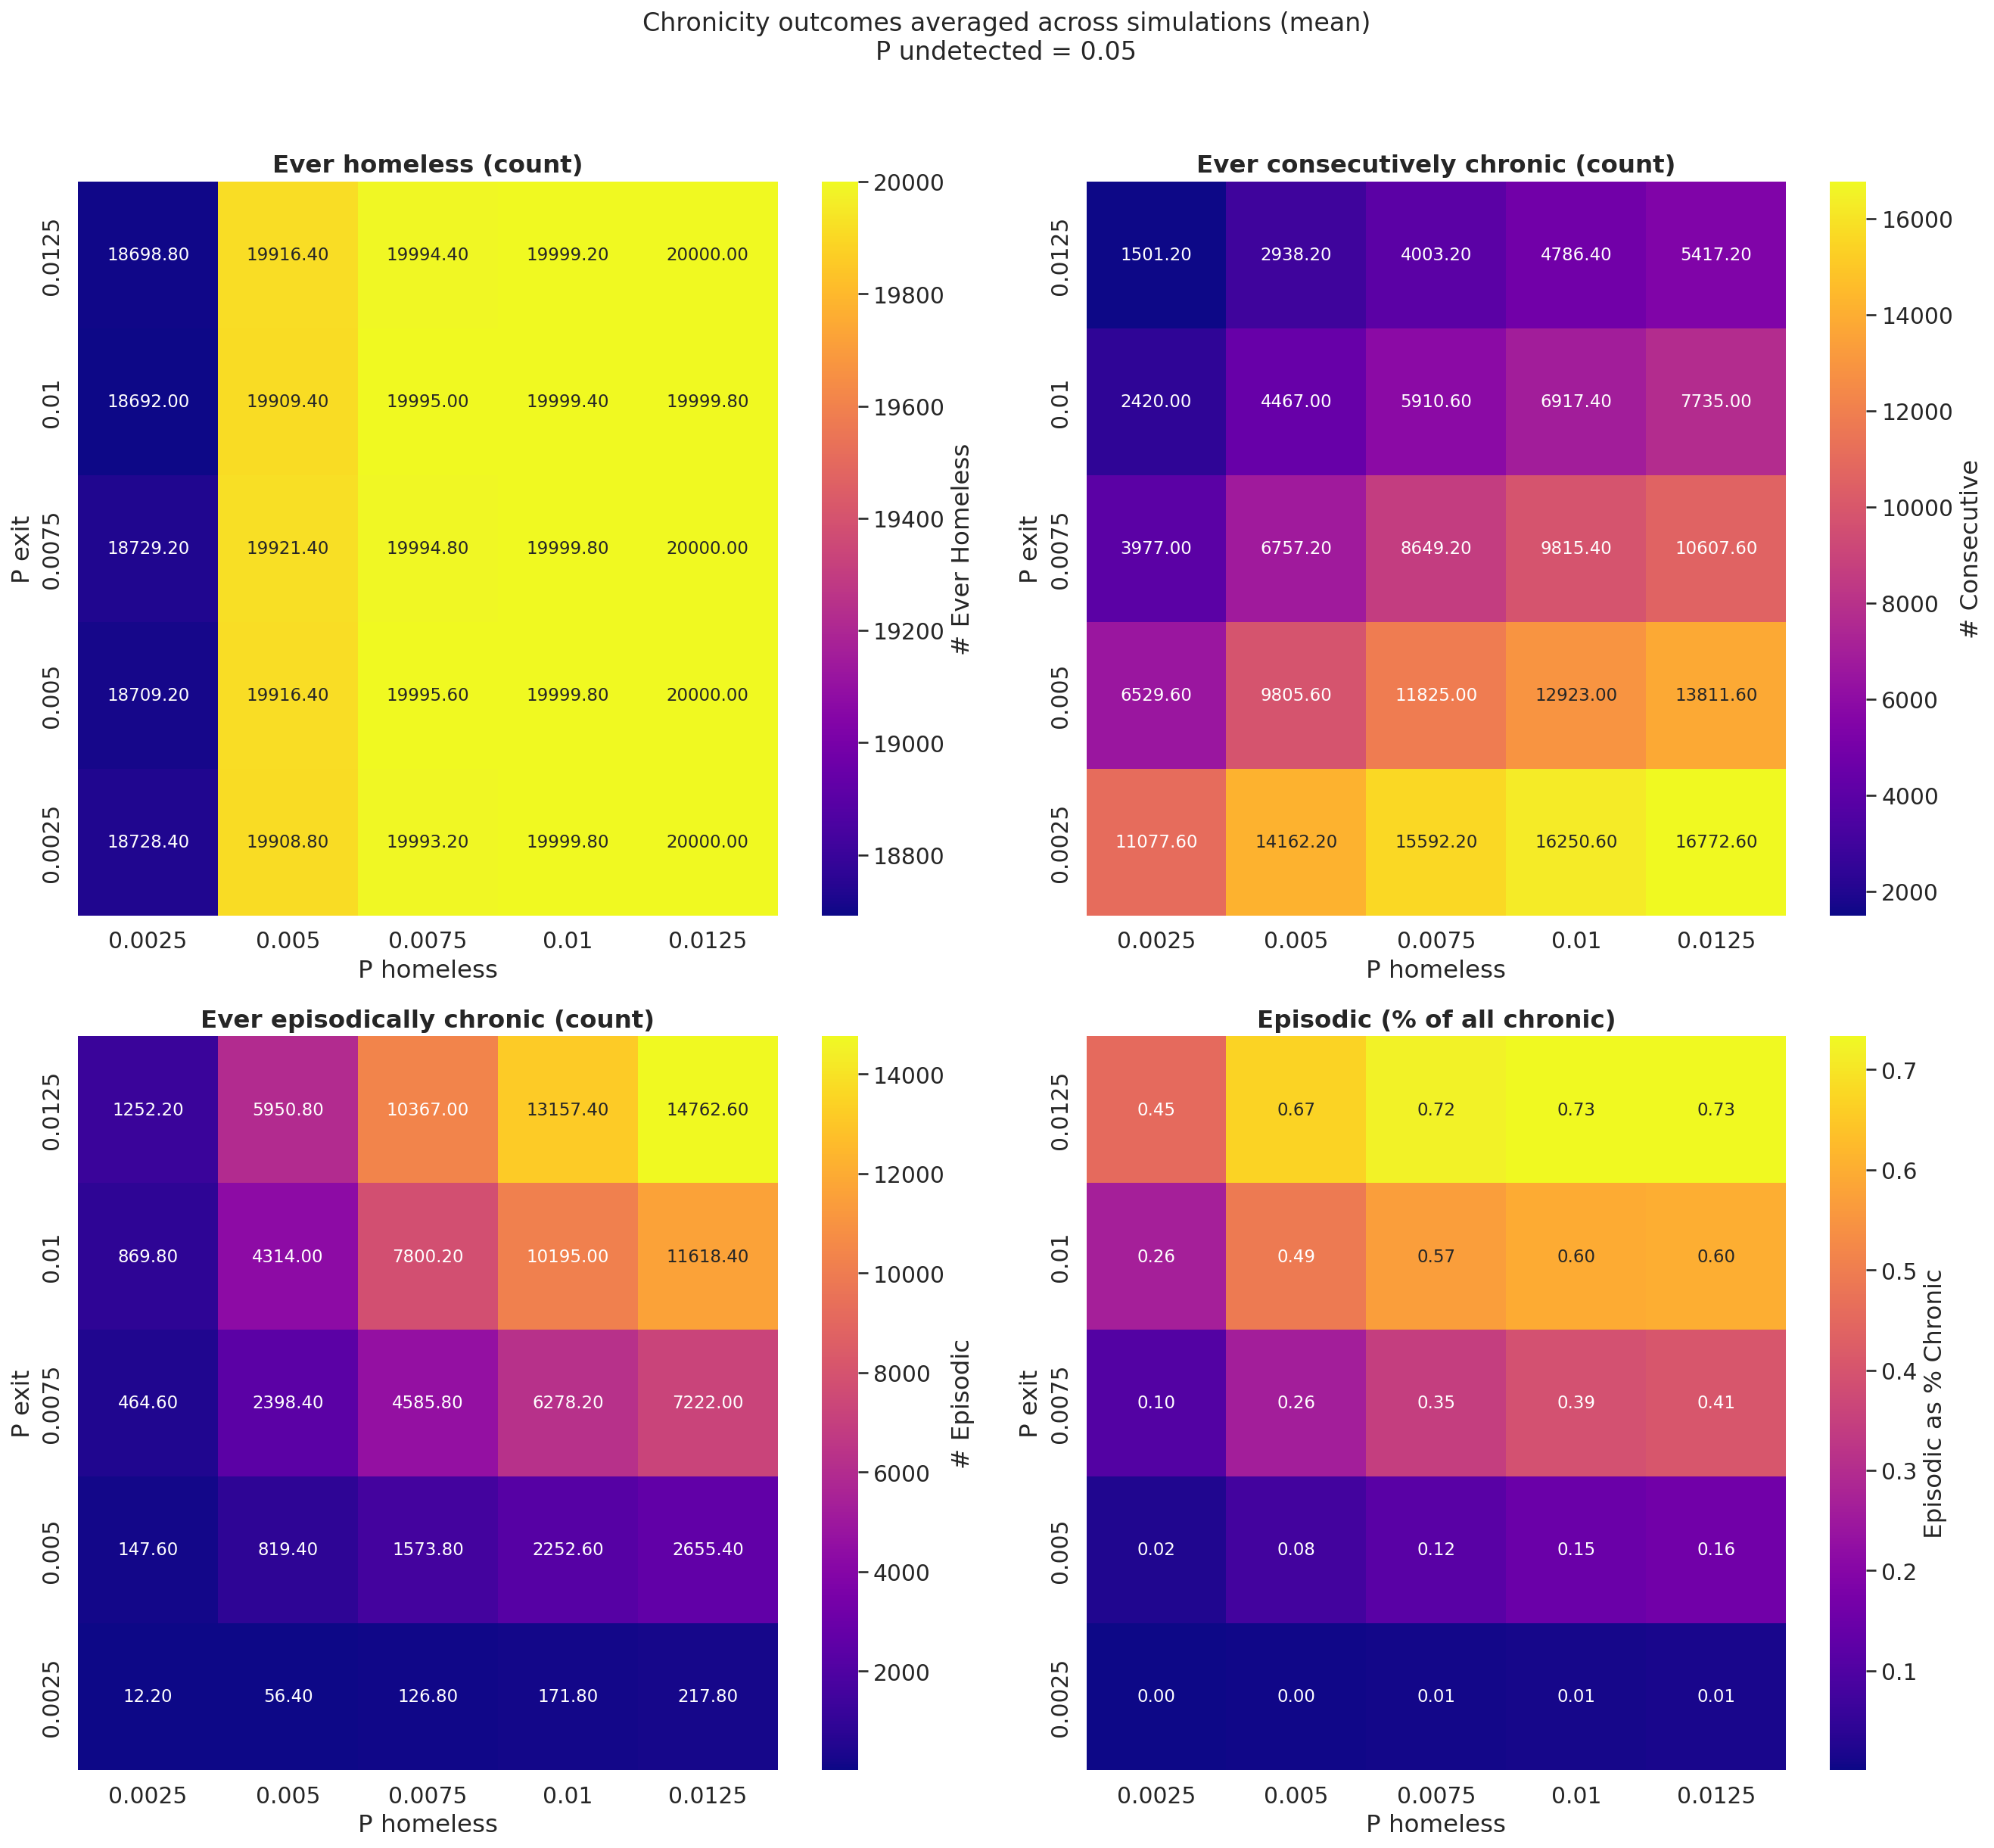

In [7]:
fig1 = plot_heatmap_grid(summary_df, x_param="P homeless", y_param="P exit",
                          save_path="final_images/heatmaps_v2.png")
plt.show()

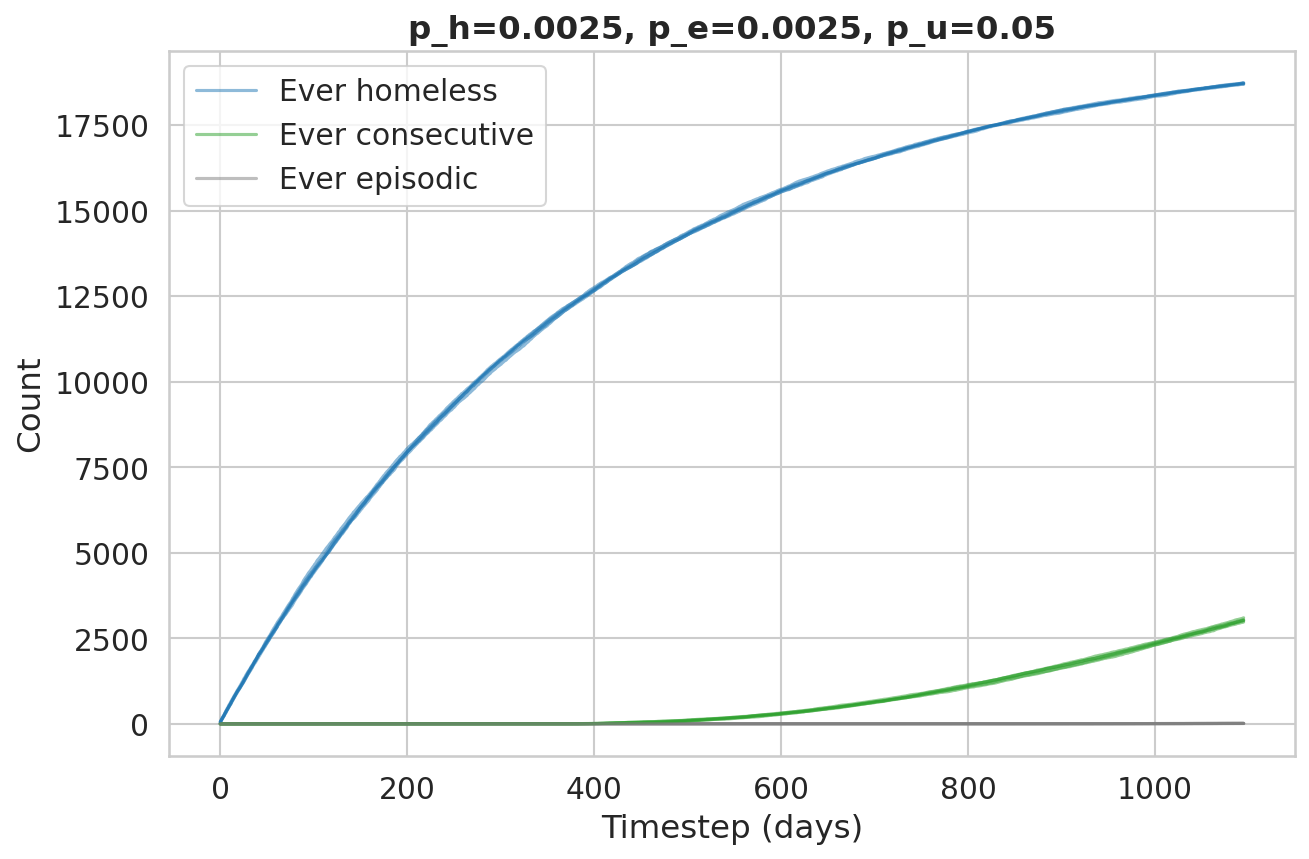

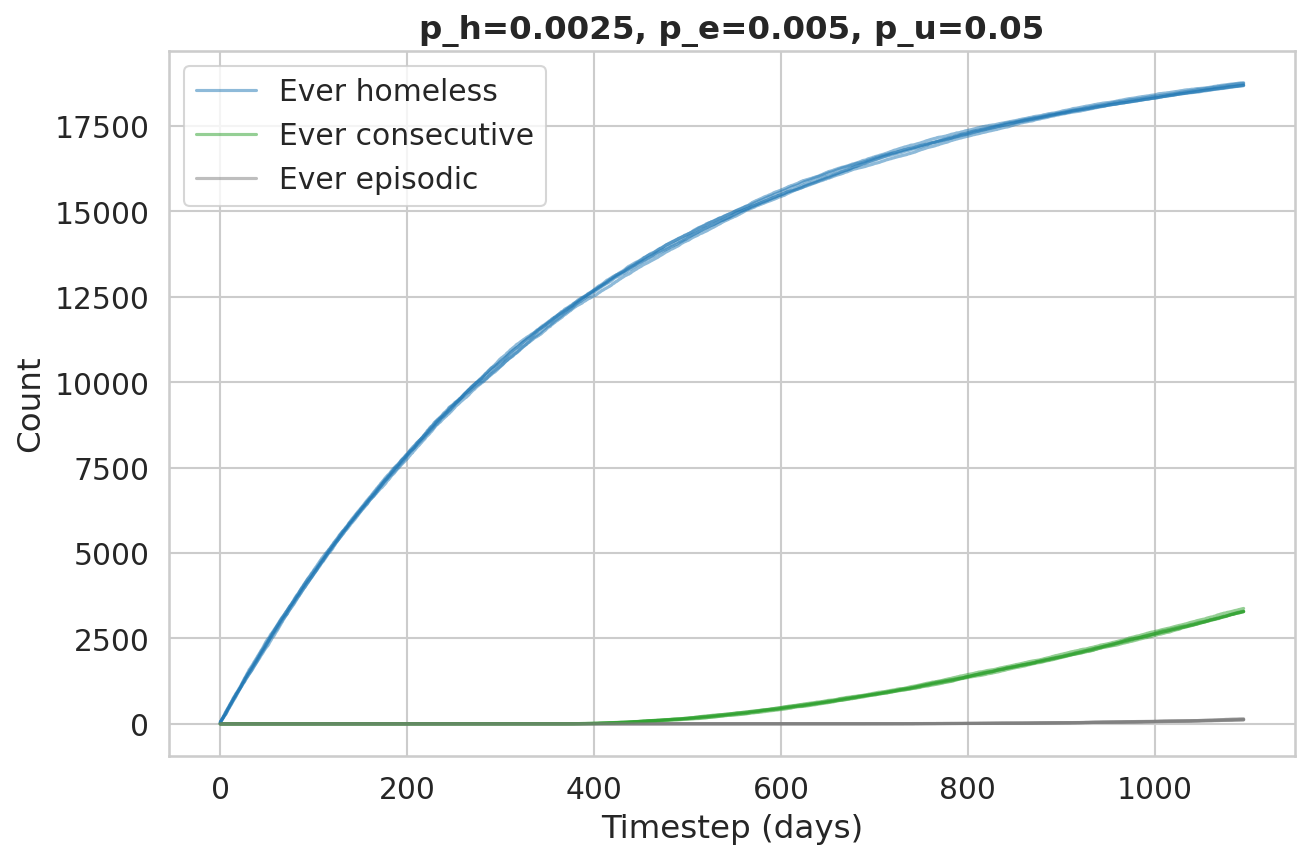

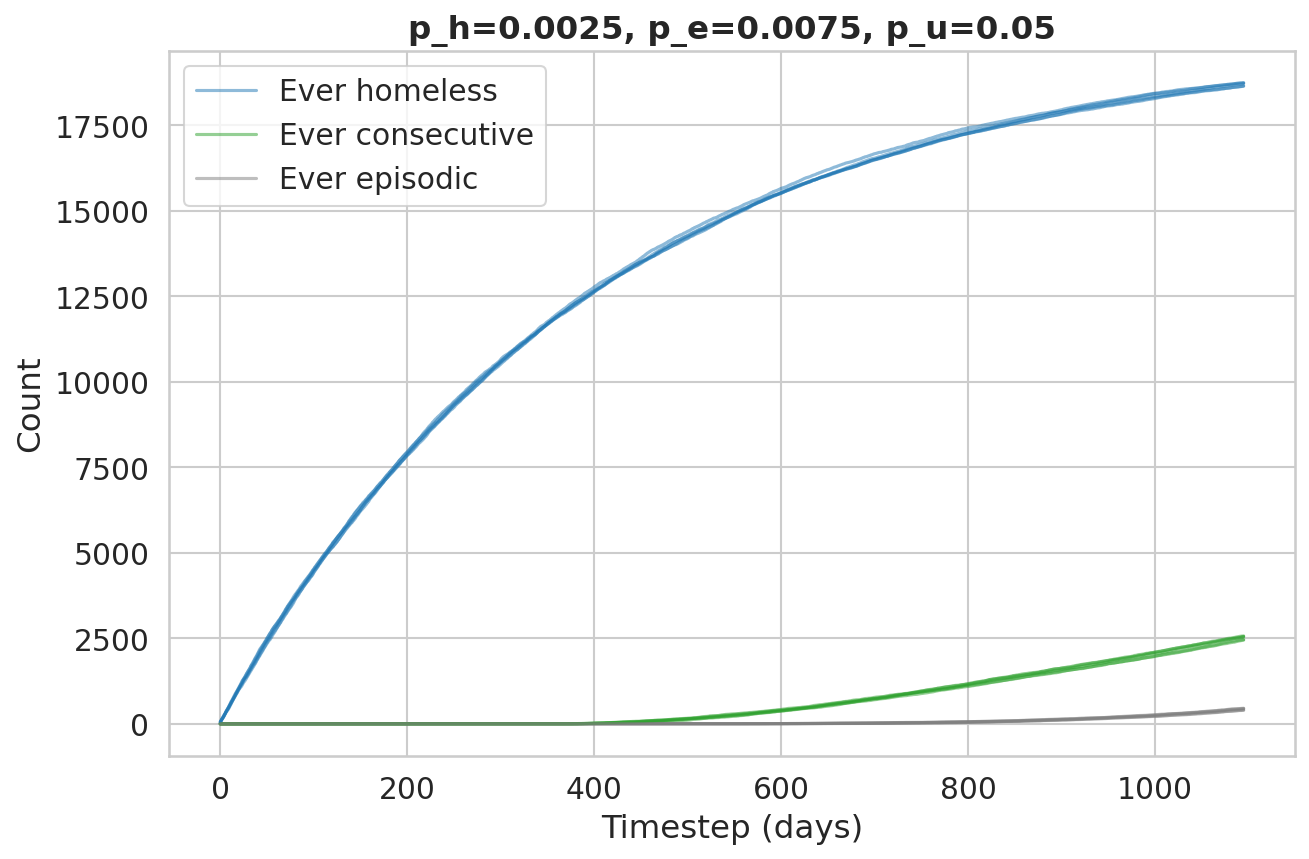

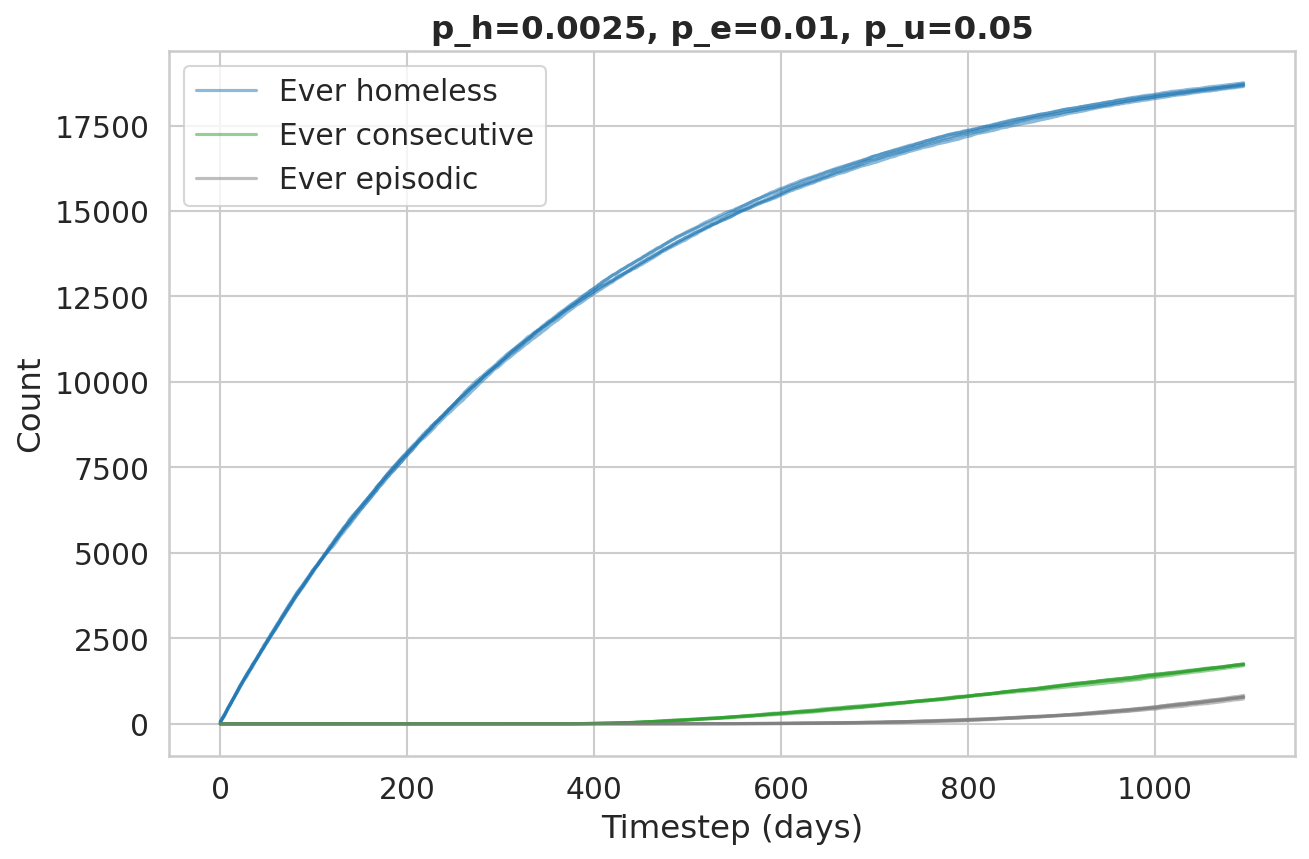

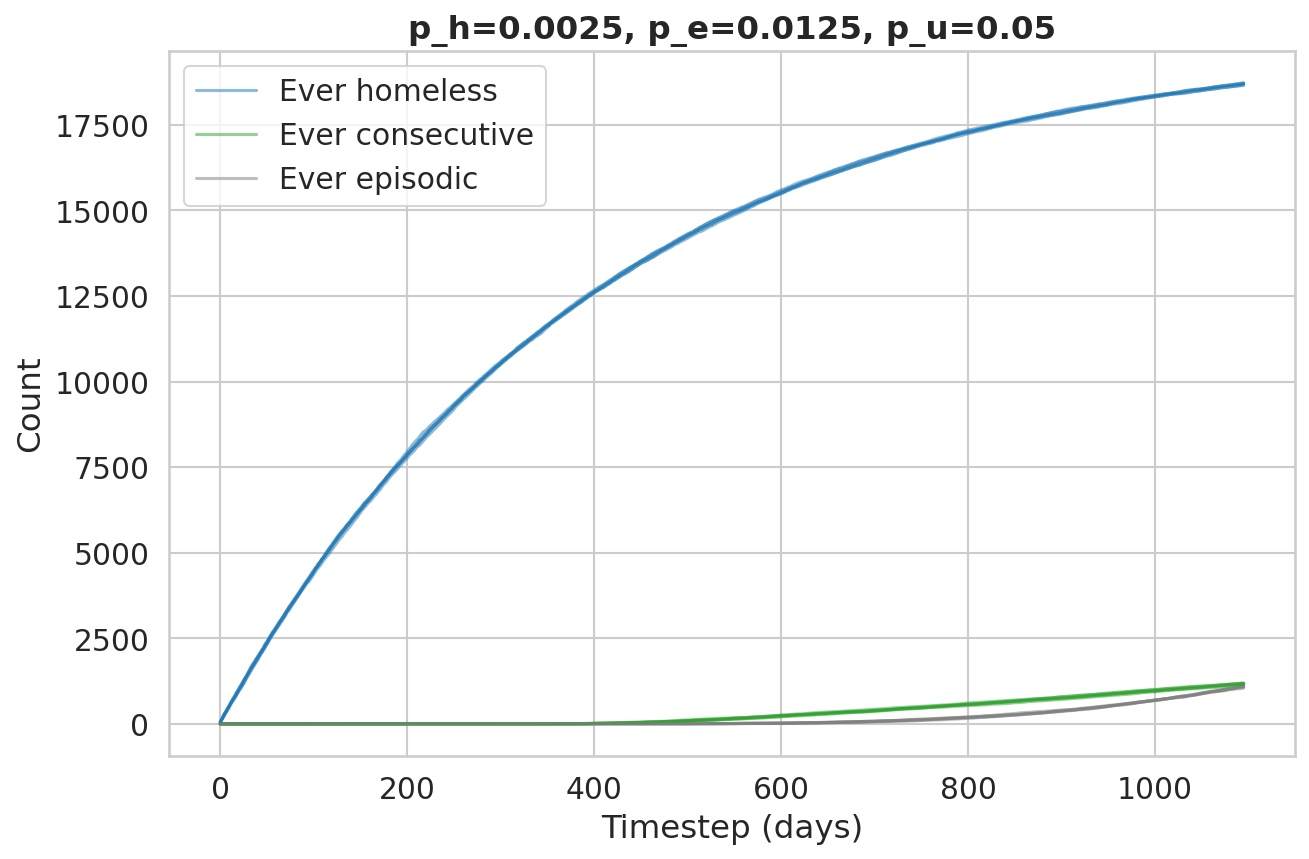

/tmp/ipykernel_53030/438885764.py:64: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


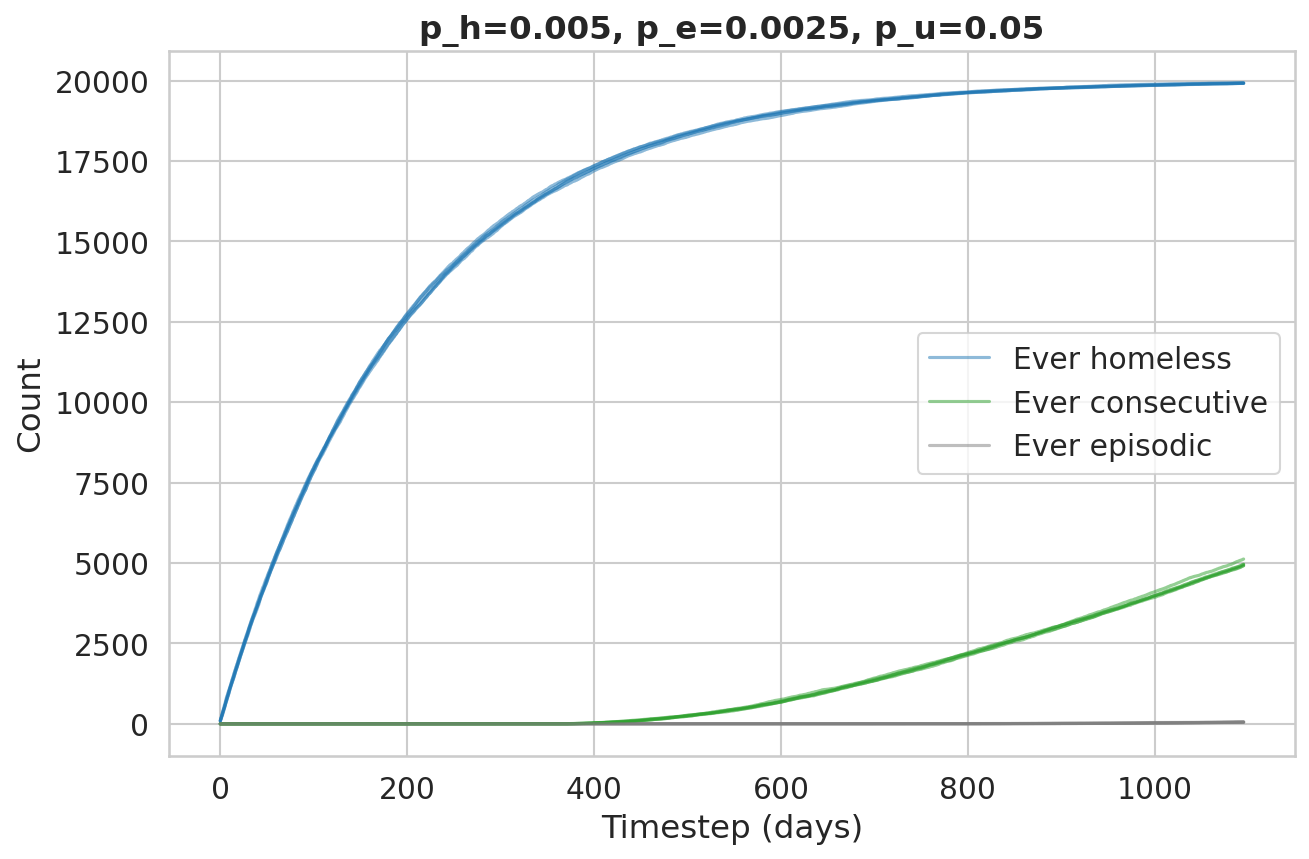

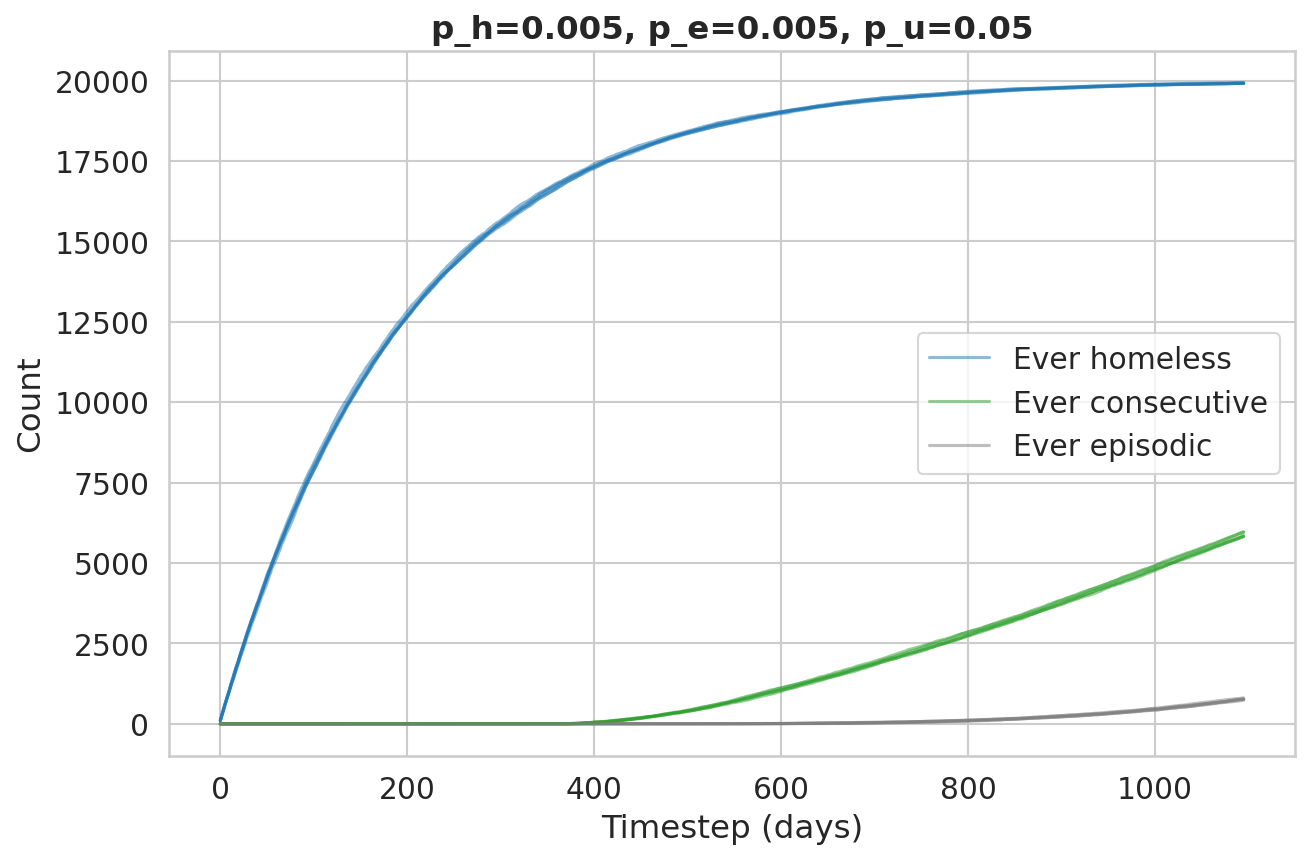

In [ ]:
for x in range(5):
  for y in range(25, 126, 25):
    for z in range(25, 126, 25):
      this_key = (x, y/10000, z/10000, 0.05)
      matching_keys = [k for k in timeseries if k[1] == this_key[1] and k[2] == this_key[2] and k[3] == this_key[3]]
      fig2 = plot_timeseries(timeseries, keys=matching_keys,
                       title=f"p_h={this_key[1]}, p_e={this_key[2]}, p_u={this_key[3]}")
      plt.show()


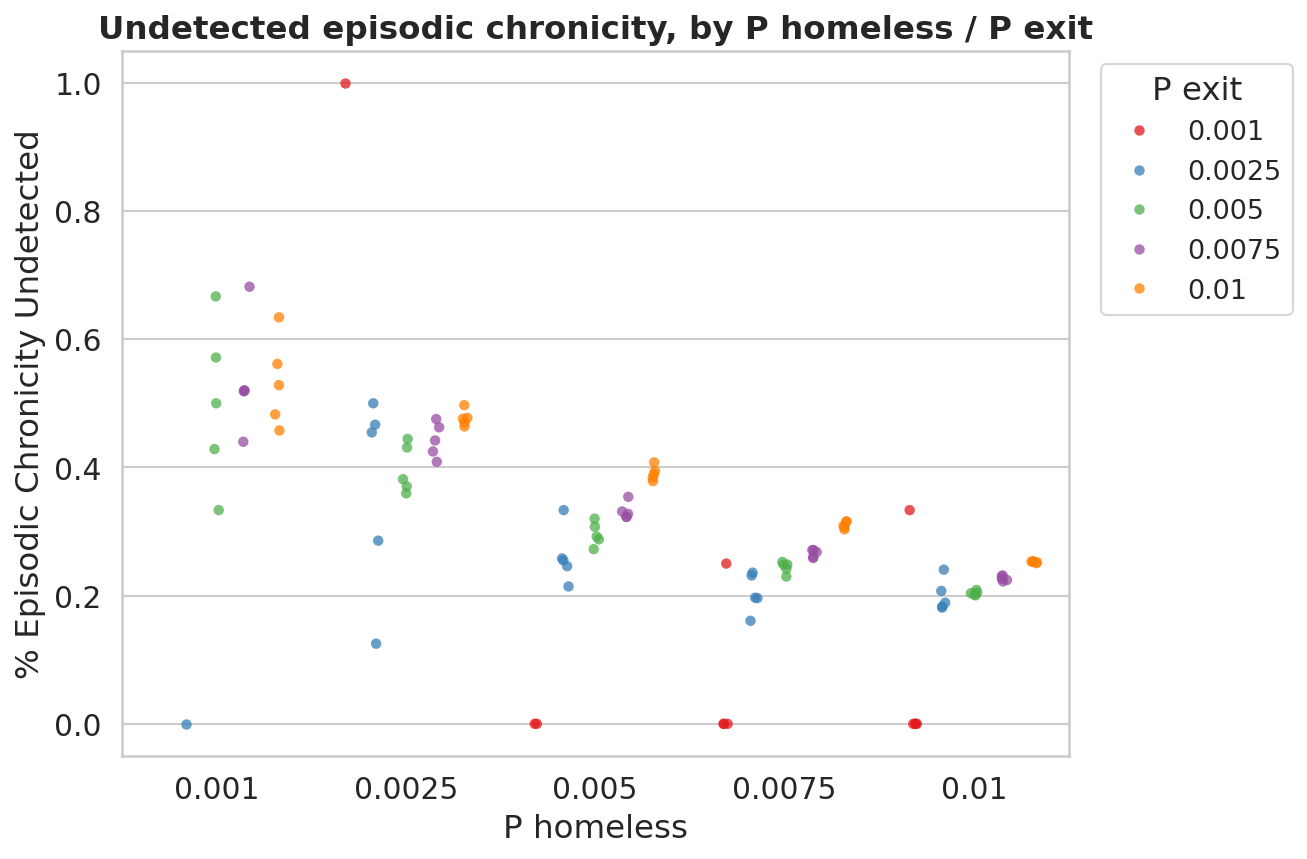

In [ ]:
fig3 = plot_undetected_stripplot(summary_df, x_param="P homeless", hue_param="P exit",
                                  save_path="final_images/undetected_stripplot_v2.png")
plt.show()

## 9. Interactive visualizations (Plotly)

Static heatmaps stop scaling once you have more than a handful of parameter
values to compare. These give you dropdowns/hover instead of needing to
regenerate a new PNG per combination. Requires `plotly`
(`pip install plotly` — Colab has it pre-installed).

In [ ]:
def plot_heatmap_grid_interactive(summary_df, x_param, y_param, metric="# Episodic", agg="mean"):
    if not HAS_PLOTLY:
        raise ImportError("plotly is required for this cell: pip install plotly")
    metrics = [m for m in METRIC_LABELS if m in summary_df.columns]
    x_vals = sorted(summary_df[x_param].unique())
    y_vals = sorted(summary_df[y_param].unique())
    fig = go.Figure()
    for m in metrics:
        pivot = summary_df.pivot_table(index=y_param, columns=x_param, values=m, aggfunc=agg)
        pivot = pivot.reindex(index=y_vals, columns=x_vals)
        fig.add_trace(go.Heatmap(z=pivot.values, x=[str(v) for v in pivot.columns],
                                  y=[str(v) for v in pivot.index], colorscale="Plasma",
                                  visible=(m == metric), texttemplate="%{z:.2f}", name=m))
    buttons = [dict(label=METRIC_LABELS.get(m, m), method="update",
                    args=[{"visible": [mm == m for mm in metrics]},
                          {"title": f"{METRIC_LABELS.get(m, m)} by {x_param} / {y_param}"}])
               for m in metrics]
    fig.update_layout(updatemenus=[dict(active=metrics.index(metric), buttons=buttons, x=1.15, y=1.1)],
                       title=f"{METRIC_LABELS.get(metric, metric)} by {x_param} / {y_param}",
                       xaxis_title=x_param, yaxis_title=y_param, width=750, height=600)
    return fig


def plot_timeseries_interactive(timeseries, summary_df):
    if not HAS_PLOTLY:
        raise ImportError("plotly is required for this cell: pip install plotly")
    p_h_vals = sorted(summary_df["P homeless"].unique())
    p_e_vals = sorted(summary_df["P exit"].unique())
    p_u_vals = sorted(summary_df["P undetected"].unique())
    default_key = next(iter(timeseries))
    fig = go.Figure()
    trace_keys = []
    for key, series in timeseries.items():
        visible = (key == default_key)
        for col, name, color in [("Ever_homeless", "Ever homeless", "red"),
                                   ("Consecutive_counts", "Ever consecutive", "blue"),
                                   ("Episodic_counts", "Ever episodic", "black")]:
            fig.add_trace(go.Scatter(x=series["Times"], y=series[col], mode="lines",
                                      line=dict(color=color), opacity=0.6,
                                      name=name, visible=visible, showlegend=visible))
            trace_keys.append(key)
    buttons = []
    for p_h in p_h_vals:
        for p_e in p_e_vals:
            for p_u in p_u_vals:
                matching = [k for k in timeseries if k[1] == p_h and k[2] == p_e and k[3] == p_u]
                if not matching:
                    continue
                vis = [k in matching for k in trace_keys]
                buttons.append(dict(label=f"ph={p_h}, pe={p_e}, pu={p_u}", method="update",
                                     args=[{"visible": vis}, {"title": f"ph={p_h}, pe={p_e}, pu={p_u}"}]))
    fig.update_layout(updatemenus=[dict(active=0, buttons=buttons, x=1.3, y=1.1)],
                       title="System-wide chronicity counts over time",
                       xaxis_title="Timestep (days)", yaxis_title="Count", width=850, height=550)
    return fig


def plot_undetected_box_interactive(summary_df, x_param, hue_param):
    if not HAS_PLOTLY:
        raise ImportError("plotly is required for this cell: pip install plotly")
    fig = px.strip(summary_df, x=x_param, y="Frac Undetected Chronic", color=hue_param,
                    stripmode="overlay", hover_data=["P homeless", "P exit", "P undetected", "Simulation"])
    fig.update_layout(title=f"Undetected episodic chronicity, by {x_param} / {hue_param}", width=800, height=550)
    return fig

In [ ]:
plot_heatmap_grid_interactive(summary_df, x_param="P homeless", y_param="P exit", metric="# Episodic")

In [ ]:
plot_timeseries_interactive(timeseries, summary_df)

In [ ]:
plot_undetected_box_interactive(summary_df, x_param="P homeless", hue_param="P exit")

## 10. PGF / statistical inference code

Carried over from the original for completeness. Your paper notes this
approach hit its own, separate computational wall: the FFT-based inference
needs an `N x N` grid where `N = pop_init * T`, so even modest population
sizes make the 2D FFT (`np.fft.fft2`) enormous (e.g. `pop_init=10,000, T=36`
gives `N=360,000`, i.e. a `360,000 x 360,000` array — far beyond available
memory). That's a fundamentally different scaling problem from the
agent-based simulation above (it's dense-array/FFT-bound, not Python-loop
bound), so it isn't addressed by the optimizations in this notebook. If you
want to push this further, the natural next steps would be (a) a sparse or
truncated-support approximation to the PGF instead of a full dense FFT grid,
or (b) reducing `pop_init`/`T` further and validating that inference is still
stable at that scale. Happy to take a pass at this specifically if you want —
it's a large enough undertaking that it seemed better to flag it here than
bury a partial attempt in this rewrite.

In [ ]:
# Unchanged from the original notebook.

def Gz(p_on, theta_hat, v, w, x, y, z):
    return (1 - p_on) * z + p_on * ((1 - theta_hat) * x + theta_hat * y * v * w)

def Gx(p_off, x, z):
    return (1 - p_off) * x + p_off * z

def Gy(p_off, w, y, z):
    return (1 - p_off) * y * w + p_off * z

def Gv(v):
    return v

def Gw(w):
    return w

def Q(n, theta_hat, pop_init, p_off, p_on, v, w, x, y, z):
    for rep in range(n):
        vp, wp = Gv(v), Gw(w)
        xp = Gx(p_off, x, z)
        yp = Gy(p_off, w, y, z)
        zp = Gz(p_on, theta_hat, v, w, x, y, z)
        x, y, z = xp, yp, zp
    return x ** pop_init

## 11. Reproduce the paper's published heatmaps, side-by-side with v2

This section runs the *exact* parameter grids behind `Figure 3` and `Figure 7`
in the paper, at full scale (`size_pop=10,000`, 5 simulations each - 125 runs
per figure, 250 runs total), and puts the resulting v2 heatmaps next to the
originals for direct comparison.

**Correction:** an earlier pass at this labeled `P_h=[0.001,0.0025,0.005,
0.0075,0.01]` / `P_e=[0.1,0.125,0.15,0.175,0.2]` as "the paper's grid" - that's
actually the *zoomed-in* grid behind Figure 5, not Figure 3. This was caught by
extracting the actual embedded heatmap images from the corrected PDF and
reading the axis values directly off of them, rather than trusting the
notebook's variable names (the original reused `P_become_homeless`/`P_exit`
across multiple cells with different values, which is exactly the kind of
mislabeling risk that motivated deriving everything below from the images
themselves). The grids below are the ones confirmed against the actual
published figures:

- **Figure 3**: `P_h = [0.001, 0.01, 0.015, 0.02, 0.025]`,
  `P_e = [0.01, 0.05, 0.1, 0.2, 0.5]`, `P_u = 0.05` (fixed)
- **Figure 5** (zoom): `P_h = [0.001, 0.0025, 0.005, 0.0075, 0.01]`,
  `P_e = [0.1, 0.125, 0.15, 0.175, 0.2]`, `P_u = 0.05` (fixed)
- **Figure 7**: `P_h = [0.001, 0.01, 0.015, 0.02, 0.025]`,
  `P_u = [0.001, 0.005, 0.01, 0.05, 0.1]`, `P_e = 0.2` (fixed)

At full scale this takes a few minutes even with the optimizations (250 runs
at N=10,000) - each `run_sweep()` call below is independent, so feel free to
run them one at a time.

In [ ]:
P_h_fig3, P_e_fig3, P_u_fig3 = [0.001, 0.01, 0.015, 0.02, 0.025], [0.01, 0.05, 0.1, 0.2, 0.5], [0.05]
P_h_fig5, P_e_fig5, P_u_fig5 = [0.001, 0.0025, 0.005, 0.0075, 0.01], [0.1, 0.125, 0.15, 0.175, 0.2], [0.05]
P_h_fig7, P_e_fig7, P_u_fig7 = [0.001, 0.01, 0.015, 0.02, 0.025], [0.2], [0.001, 0.005, 0.01, 0.05, 0.1]

# Figure 3 reproduction (~1-2 min on a 4-core machine)
df_fig3, ts_fig3 = run_sweep(P_h_fig3, P_e_fig3, P_u_fig3, numsims=5, size_pop=10_000, T=DEFAULT_T,
                               record_timeseries=False, n_workers=None)
save_sweep(df_fig3, ts_fig3, out_dir="sweep_results", tag="paper_fig3")

In [ ]:
# Figure 7 reproduction (~1-2 min on a 4-core machine)
df_fig7, ts_fig7 = run_sweep(P_h_fig7, P_e_fig7, P_u_fig7, numsims=5, size_pop=10_000, T=DEFAULT_T,
                               record_timeseries=False, n_workers=None)
save_sweep(df_fig7, ts_fig7, out_dir="sweep_results", tag="paper_fig7")

### Side-by-side comparison

`compare_with_original()` puts a saved original figure image (e.g. a PNG/JPG
you exported from the paper, or extracted from the PDF) next to the new v2
heatmap for the same grid. Point `original_image_path` at whatever image file
you have for that figure.

In [ ]:
def compare_with_original(original_image_path, summary_df, x_param, y_param, title, fixed_params_note=None):
    import io
    from PIL import Image
    Image.MAX_IMAGE_PIXELS = None  # paper figures were saved at very high resolution/DPI - not a decompression bomb

    new_fig = plot_heatmap_grid(summary_df, x_param=x_param, y_param=y_param, fixed_params_note=fixed_params_note)
    buf = io.BytesIO()
    new_fig.savefig(buf, format="png", bbox_inches="tight")
    plt.close(new_fig)
    buf.seek(0)
    new_img = Image.open(buf).convert("RGB")

    orig_img = Image.open(original_image_path).convert('RGB')
    # Downscale the original if it's very high-res (paper figures were saved at very high DPI)
    if max(orig_img.size) > 1600:
        scale = 1600 / max(orig_img.size)
        orig_img = orig_img.resize((int(orig_img.width * scale), int(orig_img.height * scale)))

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    axes[0].imshow(orig_img); axes[0].set_title("Original (published in paper)", fontsize=14); axes[0].axis("off")
    axes[1].imshow(new_img); axes[1].set_title("v2 (optimized code, same grid)", fontsize=14); axes[1].axis("off")
    fig.suptitle(title, fontsize=16, y=0.99)
    fig.tight_layout()
    return fig


# Example usage - replace with the path to your own saved Figure 3 / Figure 7 image:
# compare_with_original("final_images/heatmaps_v4.jpg", df_fig3, "P homeless", "P exit",
#                        "Figure 3: P_homeless x P_exit (P_undetected=0.05)")
# compare_with_original("final_images/heatmaps_pu.jpg", df_fig7, "P homeless", "P undetected",
#                        "Figure 7: P_homeless x P_undetected (P_exit=0.2)")

## Appendix: all three of the paper's parameter grids

For reference/convenience - same values as Section 11 above, in one place:

In [ ]:
# Figure 3 (full range)
P_h_fig3 = [0.001, 0.01, 0.015, 0.02, 0.025]
P_e_fig3 = [0.01, 0.05, 0.1, 0.2, 0.5]
P_u_fig3 = [0.05]

# Figure 5 (zoomed-in range)
P_h_fig5 = [0.001, 0.0025, 0.005, 0.0075, 0.01]
P_e_fig5 = [0.1, 0.125, 0.15, 0.175, 0.2]
P_u_fig5 = [0.05]

# Figure 7 (P_undetected sweep)
P_h_fig7 = [0.001, 0.01, 0.015, 0.02, 0.025]
P_e_fig7 = [0.2]
P_u_fig7 = [0.001, 0.005, 0.01, 0.05, 0.1]